# Querying antigen-annotated T-cell receptors

This tutorial uses the public 10x Genomics **10k Human A1101 PBMCs with EBV Spike In (BEAM-T)** dataset to combine gene expression, Antigen Capture, and paired TCR data in {class}`~mudata.MuData`. We first inspect the full dataset, then build sequence-disjoint reference, validation, and test subsets and query them with Scirpy using TCRdist and the TCRBLOSUM substitution matrices.

The assay is `HLA-A*11:01` restricted and includes EBV peptide `AVFDRKSDAK`, CMV peptide `NLVPMVATV`, and an HLA-matched negative-control peptide. Expanded anti-EBV T cells were spiked into donor PBMCs.

The evaluation below measures **agreement with BEAM-derived labels**, not biological ground truth. A receptor match does not by itself prove antigen specificity, and cells without a high EBV score are labelled **not EBV-high**. This is a BEAM-derived category, not a validated antigen-negative class.

**Sources and attribution**

- [10x Genomics dataset page](https://www.10xgenomics.com/datasets/10k-human-a1101-pbmcs-with-ebv-spike-in-beam-t-2-standard)
- [Cell Ranger Antigen Capture algorithm](https://www.10xgenomics.com/support/software/cell-ranger/latest/algorithms-overview/cr-5p-antigen-algorithm)
- [10x Loupe worked example using an antigen-specificity threshold of 90](https://www.10xgenomics.com/support/software/loupe-vdj-browser/latest/tutorials/lvb-integrated-analysis-loupe-browser)
- Dataset license: [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/)
- {func}`scirpy.pp.ir_dist` and {func}`scirpy.tl.ir_query`

In [1]:
# Hidden documentation setup: retrieve pinned public files.
import os
import warnings
from pathlib import Path

import pooch

warnings.filterwarnings(
    "ignore",
    message=r"`__version__` is deprecated, use `importlib\.metadata\.version\('scanpy'\)` instead",
    category=FutureWarning,
)
warnings.filterwarnings("ignore", message=r"Variable names are not unique.*", category=UserWarning)
warnings.filterwarnings(
    "ignore",
    message=r"Support for Awkward Arrays is currently experimental\..*",
)

CACHE_DIR = Path(os.environ.get("SCIRPY_DATA_DIR") or pooch.os_cache("scirpy")) / "tutorial-beam-t-query"
BASE_URL = (
    "https://cf.10xgenomics.com/samples/cell-vdj/7.1.0/"
    "10k_BEAM-T_Human_A1101_EBV_spikein_5pv2_10k_BEAM-T_Human_A1101_EBV_spikein_5pv2/"
)
FILES = {
    "feature_matrix": (
        "10k_BEAM-T_Human_A1101_EBV_spikein_5pv2_10k_BEAM-T_Human_A1101_EBV_spikein_5pv2_count_sample_filtered_feature_bc_matrix.h5",
        "284b22a51ec6048d14ffd6f26db09e8769bd694623982e0e8aaa5bae69d38ed5",
    ),
    "tcr_contigs": (
        "10k_BEAM-T_Human_A1101_EBV_spikein_5pv2_10k_BEAM-T_Human_A1101_EBV_spikein_5pv2_vdj_t_filtered_contig_annotations.csv",
        "3113306fa032e5b3d20d109557e04240d32c3903452d5ad154a940a68f120dca",
    ),
    "antigen_scores": (
        "10k_BEAM-T_Human_A1101_EBV_spikein_5pv2_10k_BEAM-T_Human_A1101_EBV_spikein_5pv2_antigen_analysis_antigen_specificity_scores.csv",
        "2b3302ac64bc6049d2117095c9dbd0d301d777ca30367b9d3fd96157720c6be0",
    ),
}
paths = {
    key: Path(
        pooch.retrieve(
            url=BASE_URL + filename,
            known_hash=f"sha256:{sha256}",
            path=CACHE_DIR,
            fname=filename,
            progressbar=False,
        )
    )
    for key, (filename, sha256) in FILES.items()
}

## Imports and settings

In [2]:
import matplotlib.pyplot as plt
import muon as mu
import numpy as np
import pandas as pd
import scanpy as sc
import scirpy as ir

mu.set_options(pull_on_update=False)

BEAM_SCORE_THRESHOLD = 90.0
FULL_PAIR_CATEGORIES = ["single pair", "extra VJ", "extra VDJ", "two full chains"]
EXACT_DISTANCE_KEY = "ir_dist_beam_t_exact"
QUERY_DISTANCE_KEY = "ir_dist_beam_t_query_aa_identity"
QUERY_KEY = "ir_query_beam_t_query_aa_identity"
RANDOM_STATE = 0


## Load and organize the modalities

The 10x feature matrix contains both Gene Expression and Antigen Capture features. We separate them so that antigen barcodes do not enter normalization, highly-variable-gene selection, PCA, or UMAP.

The resulting objects are:

| Object | Contents | Role |
|---|---|---|
| `mdata["gex"]` | cells × genes | transcriptomic preprocessing and UMAP |
| `mdata["antigen"]` | cells × EBV, CMV, and control features | raw Antigen Capture UMI counts |
| `mdata["airr"]` | reconstructed TCR chains | Scirpy receptor analysis |
| `antigen_scores` | one row per barcode–antigen pair | Cell Ranger scores and antigen/control UMI counts |

`reference`, `validation`, and `test` created later are ordinary MuData subsets with the same modalities.

In [3]:
adata_all = sc.read_10x_h5(paths["feature_matrix"], gex_only=False)
is_gex = adata_all.var["feature_types"].eq("Gene Expression")
is_antigen = adata_all.var["feature_types"].eq("Antigen Capture")

adata_gex = adata_all[:, is_gex].copy()
adata_antigen = adata_all[:, is_antigen].copy()
adata_gex.var_names_make_unique()
assert set(adata_antigen.var_names) == {"EBV", "CMV", "negative_control"}

adata_airr = ir.io.read_10x_vdj(paths["tcr_contigs"])
mdata = mu.MuData({"gex": adata_gex, "antigen": adata_antigen, "airr": adata_airr})

antigen_scores = pd.read_csv(paths["antigen_scores"])
assert not antigen_scores.duplicated(["barcode", "antigen"]).any()
assert set(antigen_scores["antigen"]) == {"EBV", "CMV"}
assert set(antigen_scores["control"]) == {"negative_control"}

antigen_table = antigen_scores.pivot(
    index="barcode",
    columns="antigen",
    values=["antigen_specificity_score", "antigen_umi", "control_umi"],
)
antigen_table.columns = [f"{antigen}_{field}" for field, antigen in antigen_table.columns]
antigen_table = antigen_table.rename(
    columns={
        "EBV_antigen_specificity_score": "EBV_score",
        "CMV_antigen_specificity_score": "CMV_score",
        "EBV_antigen_umi": "EBV_umi",
        "CMV_antigen_umi": "CMV_umi",
    }
)
assert antigen_table["EBV_control_umi"].equals(antigen_table["CMV_control_umi"])
antigen_table["negative_control_umi"] = antigen_table.pop("EBV_control_umi")
antigen_table = antigen_table.drop(columns="CMV_control_umi")

for modality in ("gex", "antigen", "airr"):
    mdata.mod[modality].obs = mdata.mod[modality].obs.join(antigen_table, how="left")

pd.DataFrame(
    {
        "cells": [mdata.mod["gex"].n_obs, mdata.mod["antigen"].n_obs, mdata.mod["airr"].n_obs],
        "variables": [mdata.mod["gex"].n_vars, mdata.mod["antigen"].n_vars, pd.NA],
    },
    index=["gex", "antigen", "airr"],
)

,cells,variables
gex,9798,36601
antigen,9798,3
airr,5643,<NA>


The score table contains:

- `antigen_umi`: UMI count for the target antigen;
- `control_umi`: UMI count for the paired negative-control feature;
- `antigen_specificity_score`: Cell Ranger's derived enrichment score;
- `mhc_allele`: the restricting HLA allele;
- clonotype identifiers supplied by Cell Ranger.

The specificity score is not a measure of affinity or avidity.

## Gene-expression context

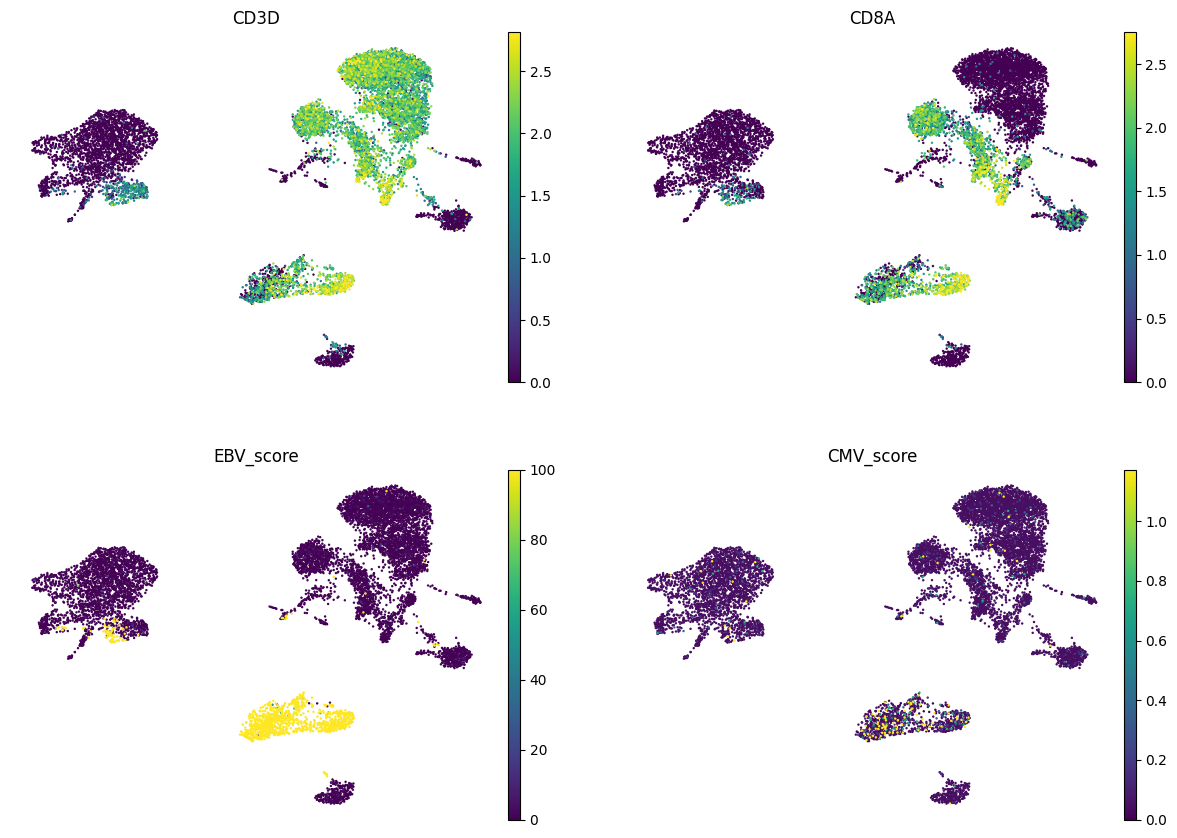

In [4]:
gex = mdata.mod["gex"]
sc.pp.filter_genes(gex, min_cells=10)
sc.pp.normalize_total(gex, target_sum=1e4)
sc.pp.log1p(gex)
sc.pp.highly_variable_genes(gex, n_top_genes=2_000)
sc.tl.pca(gex, mask_var="highly_variable")
sc.pp.neighbors(gex, n_neighbors=15, n_pcs=30)
sc.tl.umap(gex, random_state=RANDOM_STATE)

sc.pl.umap(
    gex,
    color=["CD3D", "CD8A", "EBV_score", "CMV_score"],
    ncols=2,
    frameon=False,
    vmax="p99",
)

The UMAP is descriptive: it shows the transcriptomic context of T-cell markers and continuous BEAM scores. It is not used by the receptor classifier.

## Receptor QC and BEAM-derived group labels

In [5]:
ir.pp.index_chains(mdata)
ir.tl.chain_qc(mdata)
ir.pp.ir_dist(
    mdata,
    sequence="aa",
    metric="identity",
    cutoff=0,
    key_added=EXACT_DISTANCE_KEY,
)
ir.tl.define_clonotype_clusters(
    mdata,
    sequence="aa",
    metric="identity",
    receptor_arms="all",
    dual_ir="primary_only",
    same_v_gene=False,
    key_added="exact_receptor_group",
    distance_key=EXACT_DISTANCE_KEY,
)

mdata.mod["airr"].obs["barcode"] = mdata.mod["airr"].obs_names.astype(str)
airr_obs = mdata.mod["airr"].obs.copy()
airr_obs["query_suitable"] = (
    airr_obs["receptor_subtype"].eq("TRA+TRB")
    & airr_obs["chain_pairing"].isin(FULL_PAIR_CATEGORIES)
)
airr_obs["ebv_candidate"] = (
    airr_obs["EBV_score"].ge(BEAM_SCORE_THRESHOLD)
    & airr_obs["EBV_umi"].gt(0)
)
query_suitable = airr_obs.loc[airr_obs["query_suitable"]].copy()

candidate_qc = query_suitable.loc[query_suitable["ebv_candidate"]]
qc_summary = pd.Series(
    {
        "EBV reference-candidate cells": candidate_qc.shape[0],
        "negative-control UMI > 0": candidate_qc["negative_control_umi"].gt(0).sum(),
        "CMV UMI > 0": candidate_qc["CMV_umi"].gt(0).sum(),
        "EBV UMI <= negative-control UMI": candidate_qc["EBV_umi"].le(candidate_qc["negative_control_umi"]).sum(),
        "EBV UMI <= CMV UMI": candidate_qc["EBV_umi"].le(candidate_qc["CMV_umi"]).sum(),
    },
    name="cells",
)
assert qc_summary.loc["EBV UMI <= negative-control UMI"] == 0
assert qc_summary.loc["EBV UMI <= CMV UMI"] == 0

display(
    query_suitable["chain_pairing"]
    .value_counts()
    .reindex(FULL_PAIR_CATEGORIES, fill_value=0)
    .rename_axis("chain pairing")
    .to_frame("cells")
)
display(qc_summary.to_frame())

,cells
chain pairing,
single pair,4310
extra VJ,526
extra VDJ,123
two full chains,119


,cells
EBV reference-candidate cells,362
negative-control UMI > 0,78
CMV UMI > 0,112
EBV UMI <= negative-control UMI,0
EBV UMI <= CMV UMI,0


The score already incorporates negative-control counts, so a nonzero control UMI is not by itself a reason to discard a cell. Likewise, a low nonzero CMV UMI does not imply CMV specificity. We therefore retain the score-based definition and use the antigen/control comparisons above as transparent sanity checks.

For evaluation, cells are collapsed into exact paired-receptor groups. A group receives the BEAM-derived label `EBV` if at least one member meets the conservative EBV criterion; otherwise it is labelled `other`. Exact groups are kept intact across all splits.

## Build exact-receptor reference and query subsets

We use query-suitable cells with `EBV_score >= 90` and positive EBV UMI as a conservative EBV-enriched reference. We select one deterministic representative per exact receptor group. The remaining query-suitable cells form the query subset; they are remaining cells, not validated negatives.


In [6]:
reference_barcodes = (
    query_suitable.loc[query_suitable["ebv_candidate"]]
    .sort_values(["exact_receptor_group", "barcode"])
    .drop_duplicates("exact_receptor_group")
    .index
)
query_barcodes = query_suitable.index.difference(reference_barcodes, sort=False)

def subset_from_barcodes(barcodes):
    return mu.MuData(
        {
            modality: mdata.mod[modality][barcodes].copy()
            for modality in mdata.mod
        }
    )

reference = subset_from_barcodes(reference_barcodes)
query = subset_from_barcodes(query_barcodes)

display(
    pd.DataFrame(
        {
            "cells": [reference.n_obs, query.n_obs],
            "unique exact receptor groups": [
                reference.mod["airr"].obs["exact_receptor_group"].nunique(),
                query.mod["airr"].obs["exact_receptor_group"].nunique(),
            ],
        },
        index=["reference", "query"],
    )
)


,cells,unique exact receptor groups
reference,110,110
query,4968,4409


## Query the reference receptors

We query the remaining cells against the internal reference using exact amino-acid identity with the same receptor settings that defined `exact_receptor_group`. Exact receptor identity can support biological follow-up, but it does not prove antigen specificity.


In [7]:
ir.pp.ir_dist(
    query,
    reference,
    sequence="aa",
    metric="identity",
    cutoff=0,
    key_added=QUERY_DISTANCE_KEY,
)
ir.tl.ir_query(
    query,
    reference,
    sequence="aa",
    metric="identity",
    receptor_arms="all",
    dual_ir="primary_only",
    same_v_gene=False,
    match_columns=None,
    distance_key=QUERY_DISTANCE_KEY,
    key_added=QUERY_KEY,
)
pairs = ir.tl.ir_query_annotate_df(
    query,
    reference,
    sequence="aa",
    metric="identity",
    include_query_cols=[
        "barcode", "EBV_score", "CMV_score", "EBV_umi", "CMV_umi",
        "negative_control_umi", "exact_receptor_group",
    ],
    include_ref_cols=[
        "barcode", "EBV_score", "CMV_score", "EBV_umi", "CMV_umi",
        "negative_control_umi", "exact_receptor_group",
    ],
    suffix="_ref",
    query_key=QUERY_KEY,
).rename(columns={"barcode_ref": "reference_barcode"})

matched_barcodes = pairs.index.unique()
query.mod["airr"].obs["match_status"] = pd.Categorical(
    np.where(query.mod["airr"].obs_names.isin(matched_barcodes), "matched", "unmatched"),
    categories=["matched", "unmatched"],
)
query.mod["airr"].obs["query_score_group"] = pd.Categorical(
    np.where(
        query.mod["airr"].obs["EBV_score"].ge(BEAM_SCORE_THRESHOLD)
        & query.mod["airr"].obs["EBV_umi"].gt(0),
        "EBV score >= 90 with EBV UMI > 0",
        "remaining query-suitable cells",
    ),
    categories=["remaining query-suitable cells", "EBV score >= 90 with EBV UMI > 0"],
)

display(
    pairs[
        ["reference_barcode", "EBV_score", "EBV_score_ref", "CMV_score", "CMV_score_ref", "exact_receptor_group"]
    ].head(10)
)


,reference_barcode,EBV_score,EBV_score_ref,CMV_score,CMV_score_ref,exact_receptor_group
AACACGTCACCAGTTA-1,CTGCCTAGTCTCACCT-1,0.042,100.0,0.042,0.042,65
AACGTTGAGCCGCCTA-1,CATATGGTCACGGTTA-1,0.042,100.0,0.042,0.042,92
AACGTTGGTCACCTAA-1,AACACGTCAGTAAGCG-1,100.000,100.0,0.042,0.159,66
AACGTTGGTTGGACCC-1,CATATGGTCACGGTTA-1,0.042,100.0,0.042,0.042,92
AACTCAGGTAAACGCG-1,AACACGTCAGTAAGCG-1,100.000,100.0,0.000,0.159,66
AAGCCGCGTGCGGTAA-1,AACACGTCAGTAAGCG-1,100.000,100.0,0.042,0.159,66
AAGGCAGCAGAGCCAA-1,CATATGGTCACGGTTA-1,0.376,100.0,0.042,0.042,92
AATCCAGTCATATCGG-1,AACACGTCAGTAAGCG-1,100.000,100.0,0.042,0.159,66
ACACCAAAGGGAGTAA-1,CATATGGTCACGGTTA-1,0.042,100.0,0.042,0.042,92
ACACCAAAGTACATGA-1,AACACGTCAGTAAGCG-1,100.000,100.0,0.060,0.159,66


## Summarize exact-receptor query results

,value
query-suitable cells,5078
EBV reference-candidate cells,362
remaining query-suitable cells,4716
reference cells,110
query cells,4968
match pairs,357
unique matched query cells,357
matched EBV-high query cells,252
matched remaining query cells,105
unmatched query cells,4611


query_score_group,remaining query-suitable cells,EBV score >= 90 with EBV UMI > 0
match_status,,
matched,105.0,252.0
unmatched,4611.0,0.0


<Axes: title={'center': 'Number of cells in match_status by query_score_group'}, xlabel='match_status', ylabel='Number of cells'>

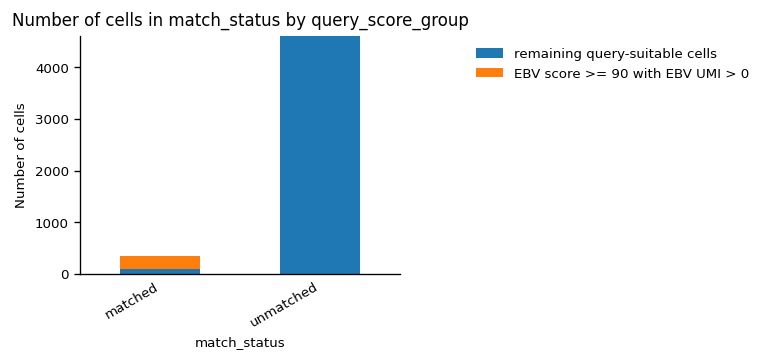

In [8]:
display(
    pd.DataFrame(
        {
            "value": [
                query_suitable.shape[0],
                int(query_suitable["ebv_candidate"].sum()),
                int((~query_suitable["ebv_candidate"]).sum()),
                reference.n_obs,
                query.n_obs,
                len(pairs),
                len(matched_barcodes),
                int(query.mod["airr"].obs.loc[matched_barcodes, "query_score_group"].eq("EBV score >= 90 with EBV UMI > 0").sum()),
                int(query.mod["airr"].obs.loc[matched_barcodes, "query_score_group"].eq("remaining query-suitable cells").sum()),
                query.n_obs - len(matched_barcodes),
            ]
        },
        index=[
            "query-suitable cells", "EBV reference-candidate cells", "remaining query-suitable cells",
            "reference cells", "query cells", "match pairs", "unique matched query cells",
            "matched EBV-high query cells", "matched remaining query cells", "unmatched query cells",
        ],
    )
)
display(ir.tl.group_abundance(query.mod["airr"], groupby="match_status", target_col="query_score_group", sort="alphabetical"))
ir.pl.group_abundance(query.mod["airr"], groupby="match_status", target_col="query_score_group", sort="alphabetical")


## Interpretation and limitations

- The threshold of 90 is illustrative and is used only to select a conservative EBV-enriched reference subset.
- `remaining` or `not EBV-high` cells are not validated antigen-negative cells.
- Exact receptor identity and `exact_receptor_group` membership do not prove antigen specificity.
- This tutorial demonstrates a subset-against-subset receptor query within one dataset, not an independent predictive validation.
- A sequence-disjoint TCRdist/TCRBLOSUM evaluation was explored with cutoffs no greater than 25, but reached at most 4.5% validation coverage in this small dataset; it is therefore not used as a classifier benchmark.
